In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame(
    data= [[ 1., 2., 3., 4.],
           [ 5., 6., np.nan, 8.],
           [ 10., 11., 12., np.nan]],
    columns=['A','B','C','D']
)
df

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,NaN,8.0
2,10.0,11.0,12.0,NaN


# Removing and imputing missing values from the dataset

## Identifying missing values in tabular data

In [4]:
df.isnull()

,A,B,C,D
0,False,False,False,False
1,False,False,True,False
2,False,False,False,True


In [ ]:
df.isnull().sum() # df.isna().sum()

A    0
B    0
C    1
D    1
dtype: int64

## Eliminating training examples or features with missing values

In [ ]:
df.dropna(axis=0) # Dropping rows with nans

,A,B,C,D
0,1.0,2.0,3.0,4.0


In [ ]:
df.dropna(axis=1) # Droping columns with nans

,A,B
0,1.0,2.0
1,5.0,6.0
2,10.0,11.0


> To learn more about dealing with missing data using Pandas, check out the [official documentation](https://pandas.pydata.org/docs/reference/frame.html#missing-data-handling)

## Imputing missing values

In [ ]:
df.fillna(df.mean()) # The easiest way using each colum mean

,A,B,C,D
0,1.0,2.0,3.0,4.0
1,5.0,6.0,7.5,8.0
2,10.0,11.0,12.0,6.0


In [13]:
from sklearn.impute import SimpleImputer
import numpy as np
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
imr = imr.fit(df.values)
imputed_data = imr.transform(df.values)
imputed_data

array([[ 1. ,  2. ,  3. ,  4. ],
       [ 5. ,  6. ,  7.5,  8. ],
       [10. , 11. , 12. ,  6. ]])

> For detailed information on how to impute data using scikit-learn, refer to the [`sklearn.impute` documentation](https://scikit-learn.org/stable/api/sklearn.impute.html).

# Handling categorical data

Categorical data can be divided into two groups: **ordinal** and **nominal**. An ordinal feature has categorical values that can be ordered. For example, t-shirt sizes can be ordered as follows: XL > L > M. Besides, nominal data cannot be ordered. Attempting to do so is mathematically meaningless. For example, t-shirt color.

In [1]:
import pandas as pd
df = pd.DataFrame([
    ['green', 'M', 10.1, 'class2'],
    ['red', 'L', 13.5, 'class1'],
    ['blue', 'XL', 15.3, 'class2']
])
df.columns = ['color', 'size', 'price', 'classlabel']
df

,color,size,price,classlabel
0,green,M,10.1,class2
1,red,L,13.5,class1
2,blue,XL,15.3,class2


## Mapping ordinal features

In [ ]:
size_mapping = { # Create a dictionary to map values
    'XL': 3,
    'L': 2,
    'M': 1
}
df['size'] = df['size'].map(size_mapping)
df

,color,size,price,classlabel
0,green,1,10.1,class2
1,red,2,13.5,class1
2,blue,3,15.3,class2


## Encoding class labels

In [4]:
from sklearn.preprocessing import LabelEncoder
class_le = LabelEncoder()
y = class_le.fit_transform(df['classlabel'].values)
print(f'classes encaded: {y}')
class_le.inverse_transform(y)

classes encaded: [1 0 1]


array(['class2', 'class1', 'class2'], dtype=object)

## one-hot encoding on nominal features

The idea behind this approach is to create a new dummy feature for each unique value in the nominal feature column.

In [10]:
from sklearn.preprocessing import OneHotEncoder # Using sklearn
from sklearn.compose import ColumnTransformer

X = df[['color', 'size', 'price']].values
c_transf = ColumnTransformer([
    ('onehot', OneHotEncoder(), [0]),
    ('nothing', 'passthrough', [1, 2]),
    # drop'first'
])
c_transf.fit_transform(X).astype(float)

array([[ 0. ,  1. ,  0. ,  1. , 10.1],
       [ 0. ,  0. ,  1. ,  2. , 13.5],
       [ 1. ,  0. ,  0. ,  3. , 15.3]])

In [11]:
pd.get_dummies(df[['price','color','size']], dtype=float, drop_first=True)

,price,size,color_green,color_red
0,10.1,1,1.0,0.0
1,13.5,2,0.0,1.0
2,15.3,3,0.0,0.0


> This encoder introduces new features that can cause multicollinearity. To avoid highly correlated features, a good practice is to drop one from the encoded array (normally the first one). [Scikit-learn has a complete module dedicated to preprocessing data and encoding features.](https://scikit-learn.org/stable/api/sklearn.preprocessing.html)

# Bringing features onto the same scale

To ensure Machine Learning algorithms (especially optimization algorithms like gradient descent) work properly, features must be on the same scale. There are two common approaches:

**1. Normalization (Min-Max Scaling)**
* Rescales all feature values to fit within a bounded interval, typically $[0, 1]$.
$$x^{(i)}_{norm} = \frac{x^{(i)} - x_{min}}{x_{max} - x_{min}}$$
*   **Drawback:** It is highly sensitive to outliers. A single extreme high value will become $1$, compressing all other typical values very close to $0$.

**2. Standardization**
* Centers the data to have a **mean of zero** ($\mu = 0$) and a **standard deviation of one** ($\sigma = 1$), giving it the parameters of a standard normal distribution.
$$x^{(i)}_{std} = \frac{x^{(i)} - \mu_x}{\sigma_x}$$
* **Shape remains unchanged:** Standardization does **not** transform non-normally distributed data into a perfect bell curve; the original shape of the distribution is preserved.
* **Robustness to Outliers:** Unlike Min-Max scaling, it does not restrict data to a limited range. This maintains useful information about outliers and makes the algorithm much less sensitive to them.
* **Easier Optimization:** Centering the data at $0$ makes it significantly easier for algorithms to learn and adjust their mathematical weights.

In [9]:
from sklearn.datasets import load_wine
data, target = load_wine(return_X_y=True, as_frame=True)
data

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
X, y = data.values, target.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
mms = MinMaxScaler()
X_train_norm = mms.fit_transform(X_train)
X_test_norm = mms.transform(X_test)
X_train_norm

array([[0.64619883, 0.83201581, 0.4248366 , ..., 0.45744681, 0.28571429,
        0.19400856],
       [0.6871345 , 0.15612648, 0.65359477, ..., 0.81914894, 0.63369963,
        0.68259629],
       [0.67836257, 0.15019763, 0.65359477, ..., 0.75531915, 0.52747253,
        0.71825963],
       ...,
       [0.72222222, 0.84980237, 0.34640523, ..., 0.10638298, 0.02197802,
        0.09771755],
       [0.16081871, 0.06916996, 0.39215686, ..., 0.54255319, 0.68131868,
        0.43366619],
       [0.37719298, 0.61857708, 0.45751634, ..., 0.75531915, 0.68131868,
        0.13195435]], shape=(124, 13))

In [4]:
from sklearn.preprocessing import StandardScaler
stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)
X_train_std

array([[ 0.71225893,  2.22048673, -0.13025864, ..., -0.20017028,
        -0.82164144, -0.62946362],
       [ 0.88229214, -0.70457155,  1.17533605, ...,  1.33982592,
         0.54931269,  1.47568796],
       [ 0.84585645, -0.73022996,  1.17533605, ...,  1.06806189,
         0.1308109 ,  1.62934866],
       ...,
       [ 1.02803489,  2.29746195, -0.5778911 , ..., -1.69487249,
        -1.86068037, -1.04434751],
       [-1.30384913, -1.08089484, -0.31677217, ...,  0.16218176,
         0.73691694,  0.40313628],
       [-0.40510216,  1.29678411,  0.05625489, ...,  1.06806189,
         0.73691694, -0.89683324]], shape=(124, 13))

> Furthermore, the most common feature scaling techniques are readily available through the [scikit-learn preprocessing module](https://scikit-learn.org/stable/api/sklearn.preprocessing.html).

# Selecting meaningful features

## L1 Regularization for Feature Selection

L1 regularization reduces model complexity by penalizing the sum of the absolute values of the weights, rather than their squares.

$$L1: \|\mathbf{w}\|_1 = \sum_{j=1}^{m} |w_j|$$

Unlike L2, L1 typically yields **sparse feature vectors**. This means it forces the majority of the feature weights to become exactly $0$. This sparsity is perfect for high-dimensional datasets. By turning the weights of useless features to $0$, L1 acts as a built-in feature selection tool, leaving you with a robust model that ignores irrelevant data. You can enforce even more sparsity (forcing more features to $0$) by increasing the regularization strength. In libraries like scikit-learn, you do this by choosing lower values for the $C$ parameter.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
lr_multiclass = OneVsRestClassifier(
    LogisticRegression(
        # penalty='l1',
        l1_ratio=1,
        C=1.0,
        solver='liblinear'
    )
)
lr_multiclass.fit(X_train_std, y_train)
print('Training accuracy:', lr_multiclass.score(X_train_std, y_train))
print('Testing accuracy:', lr_multiclass.score(X_test_std, y_test))

Training accuracy: 1.0
Testing accuracy: 1.0


In [6]:
for i in lr_multiclass.estimators_:
    print(i.intercept_, i.coef_)

[-1.26352157] [[ 1.24642677  0.18062977  0.74641403 -1.1644385   0.          0.
   1.15940415  0.          0.          0.          0.          0.55913555
   2.50841902]]
[-1.21604547] [[-1.53688448 -0.38717185 -0.995284    0.36484737 -0.0596865   0.
   0.66790652  0.          0.         -1.93412008  1.23388576  0.
  -2.23179097]]
[-2.36987516] [[ 0.13566158  0.16840289  0.35722482  0.          0.          0.
  -2.43821167  0.          0.          1.56404397 -0.81887872 -0.4919336
   0.        ]]


## Sequential feature selection algorithms

**The Sequential Backward Selection algorithm (SBS)** is a dimensionality reduction algorithm that aims to shrink an initial feature space from $d$ dimensions down to a smaller desired subset of $k$ dimensions ($k < d$). Its goal is to do this with a minimal decay in the model's performance, which improves computational efficiency and helps prevent overfitting.

> A "Greedy" Algorithm: SBS belongs to a family of *greedy search algorithms*. Instead of exhaustively evaluating every single possible combination of features (which is computationally unfeasible for large datasets), a greedy algorithm makes the best *local* decision at each step. While it might yield a slightly suboptimal final solution, it is vastly faster and more efficient.

The algorithm sequentially removes features one by one from the dataset. To decide which feature gets the axe, it evaluates a criterion function ($J$). At every stage, it simply eliminates the feature that causes the **least performance loss** to the classifier after it is removed.

**The 4-Step Process**
1.  **Initialize:** Start with the full feature space $X_d$ and set your starting count to $k = d$.
2.  **Evaluate:** Identify the feature $x^-$ that maximizes the criterion $J$ (i.e., the one whose removal hurts the model the least):
    $$x^- = \text{argmax } J(X_k - x)$$
    *(where $x \in X_k$)*
3.  **Remove:** Delete that feature $x^-$ from your current feature set, and update your counter:
    $$X_{k-1} = X_k - x^-$$
    $$k = k - 1$$
4.  **Terminate:** If $k$ has reached your target number of desired features, stop. Otherwise, go back to step 2 and repeat.

In [7]:
from sklearn.base import clone
from itertools import combinations
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

class SBS:
    def __init__(
       self,
       estimator,
       k_features,
       scoring=accuracy_score,
       test_size=0.25,
       random_state=1
    ):
        self.scoring = scoring
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.test_size = test_size
        self.random_state = random_state

    def fit(self, X, y):
        X_train, X_test, y_train, y_test = \
        train_test_split(X, y, test_size=self.test_size,
        random_state=self.random_state)

        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X_train, y_train,
        X_test, y_test, self.indices_)
        self.scores_ = [score]
        
        while dim > self.k_features:
            scores = []
            subsets = []

            for p in combinations(self.indices_, r=dim - 1):
                score = self._calc_score(X_train, y_train, X_test, y_test, p)
                scores.append(score)
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1
            self.scores_.append(scores[best])

        self.k_score_ = self.scores_[-1]
        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, y_train, X_test, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        y_pred = self.estimator.predict(X_test[:, indices])
        score = self.scoring(y_test, y_pred)
        return score


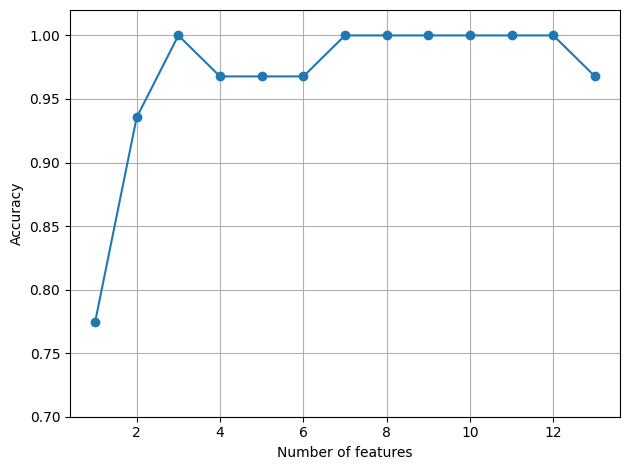

In [8]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
sbs = SBS(knn, k_features=1)
sbs.fit(X_train_std, y_train)

k_feat = [len(k) for k in sbs.subsets_]
plt.plot(k_feat, sbs.scores_, marker='o')
plt.ylim([0.7, 1.02])
plt.ylabel('Accuracy')
plt.xlabel('Number of features')
plt.grid()
plt.tight_layout()
plt.show()

In [13]:
k3 = list(sbs.subsets_[10])
print(f'Features selected: {data.columns[k3]}')

knn.fit(X_train_std, y_train)
print('Training accuracy original data:', knn.score(X_train_std, y_train))
print('Test accuracy original data:', knn.score(X_test_std, y_test))

knn.fit(X_train_std[:, k3], y_train)
print('Training accuracy with features selected:', knn.score(X_train_std[:, k3], y_train))
print('Test accuracy with features selected:', knn.score(X_test_std[:, k3], y_test))

Features selected: Index(['alcohol', 'malic_acid', 'od280/od315_of_diluted_wines'], dtype='str')
Training accuracy original data: 0.967741935483871
Test accuracy original data: 0.9629629629629629
Training accuracy with features selected: 0.9516129032258065
Test accuracy with features selected: 0.9259259259259259


In the context of Sequential Backward Selection (SBS), the **validation dataset** serves as an internal testing environment created dynamically during the model's training phase. Because the greedy SBS algorithm must continuously evaluate the performance impact of removing individual features to make its decisions, it cannot use the original test dataset without causing data leakage and severe overfitting. To solve this, the algorithm internally splits the provided training data into a new, smaller training subset and a separate validation subset. The classifier learns from this internal training data and is then tested on the validation dataset, allowing the algorithm to safely determine which feature causes the least performance loss when removed, all while preserving the strict isolation of the original test dataset for the final model evaluation.

> SKLearn has a complete module for [Features selection](https://scikit-learn.org/stable/api/sklearn.feature_selection.html)

## Assessing feature importance with random forests

Using a Random Forest is a powerful and highly flexible approach for feature selection that measures relevance by calculating the averaged impurity decrease across all decision trees in the ensemble. This method is particularly advantageous because it does not assume the data is linearly separable and, unlike many other algorithms, tree-based models do not require features to be standardized or normalized before training. In libraries like scikit-learn, this entire process is fully automated; the algorithm conveniently computes these importance values during the training phase, allowing you to easily rank and access the most relevant features simply by calling the `feature_importances_` attribute after fitting your model.

 1) proline                        0.185453
 2) flavanoids                     0.174751
 3) color_intensity                0.143920
 4) od280/od315_of_diluted_wines   0.136162
 5) alcohol                        0.118529
 6) hue                            0.058739
 7) total_phenols                  0.050872
 8) magnesium                      0.031357
 9) malic_acid                     0.025648
10) proanthocyanins                0.025570
11) alcalinity_of_ash              0.022366
12) nonflavanoid_phenols           0.013354
13) ash                            0.013279


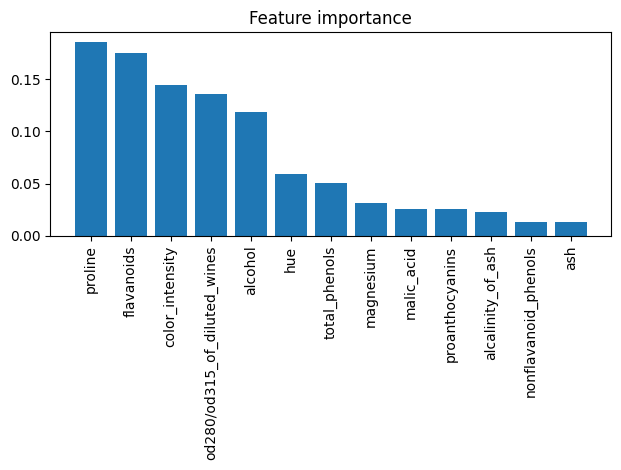

In [20]:
from sklearn.ensemble import RandomForestClassifier
feat_labels = data.columns
forest = RandomForestClassifier(n_estimators=500, random_state=1)
forest.fit(X_train, y_train)
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1] # Return indices that sort importance in descending order

for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30, feat_labels[indices[f]], importances[indices[f]]))

plt.title('Feature importance')
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]),
feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

Scikit-learn provides a very useful tool called `SelectFromModel` that automates feature selection based on a user-specified threshold. After a model like `RandomForestClassifier` is fitted and computes its feature importances, this tool automatically filters the dataset to retain only those features whose importance meets or exceeds the given limit, such as 0.1. Its greatest advantage is its design for integration as an intermediate step within a scikit-learn `Pipeline`, allowing you to seamlessly connect automated feature selection with other data preprocessing steps and your final predictive estimator.

In [22]:
from sklearn.feature_selection import SelectFromModel
sfm = SelectFromModel(forest, threshold=0.1, prefit=True)
X_selected = sfm.transform(X_train)
print('Number of features that meet this threshold', 'criterion:', X_selected.shape[1])

for f in range(X_selected.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30, feat_labels[indices[f]], importances[indices[f]]))

Number of features that meet this threshold criterion: 5
 1) proline                        0.185453
 2) flavanoids                     0.174751
 3) color_intensity                0.143920
 4) od280/od315_of_diluted_wines   0.136162
 5) alcohol                        0.118529
